## 0. Imports, Setup

We created specific utils file for each part of the project.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from text_mining_utils import (
    preprocess_pipeline,
    # EDA helpers
    plot_class_distribution, plot_tweet_length_distribution,
    plot_wordclouds, plot_top_tokens, show_preprocessing_examples,
)

DATA_DIR  = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

# Load the datasets
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

## 1. Data Exploration


In [2]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 954.7 KB


In [3]:
(train_df["label"].value_counts(normalize=True).sort_index() * 100).round(2)

label
0    15.11
1    20.15
2    64.74
Name: proportion, dtype: float64

In [4]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


### 1.2 Class Distribution

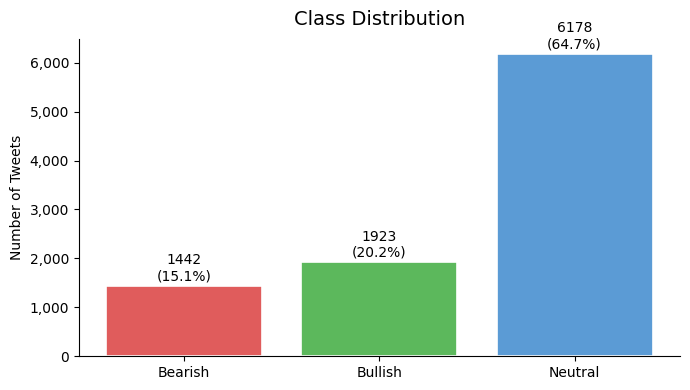

In [5]:
plot_class_distribution(train_df, label_col="label")

The majority of the dataset has as label "Neutral", showing great class imbalacement.

### 1.3 Tweet Length Distribution

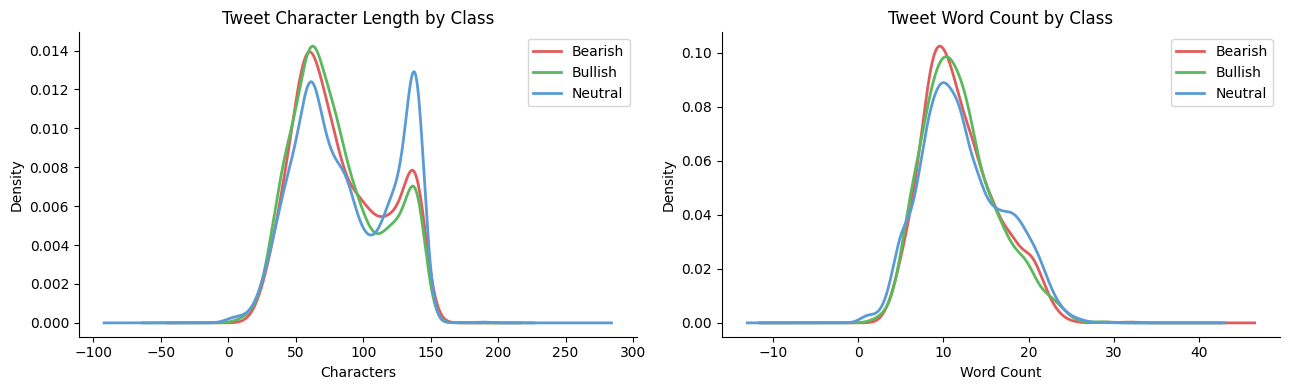

In [6]:
plot_tweet_length_distribution(train_df, text_col="text", label_col="label")

In [7]:
# Summary stats per class
train_df["char_len"]  = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df.groupby("label")[["char_len", "word_count"]].describe().round(1)

char_len                                             word_count        \
         count  mean   std   min   25%   50%    75%    max      count  mean   
label                                                                         
0       1442.0  83.3  33.0  20.0  57.2  75.5  110.8  151.0     1442.0  12.0   
1       1923.0  80.4  32.3   9.0  57.0  74.0  103.0  154.0     1923.0  11.9   
2       6178.0  88.1  36.2   2.0  59.0  82.0  125.0  190.0     6178.0  12.3   

                                        
       std  min  25%   50%   75%   max  
label                                   
0      4.3  3.0  9.0  11.0  15.0  32.0  
1      4.3  2.0  9.0  11.0  14.0  29.0  
2      4.8  1.0  9.0  12.0  16.0  29.0

We conclude that does not exist a difference between the tweet sizes and the label.

### 1.4 Word Clouds per Class

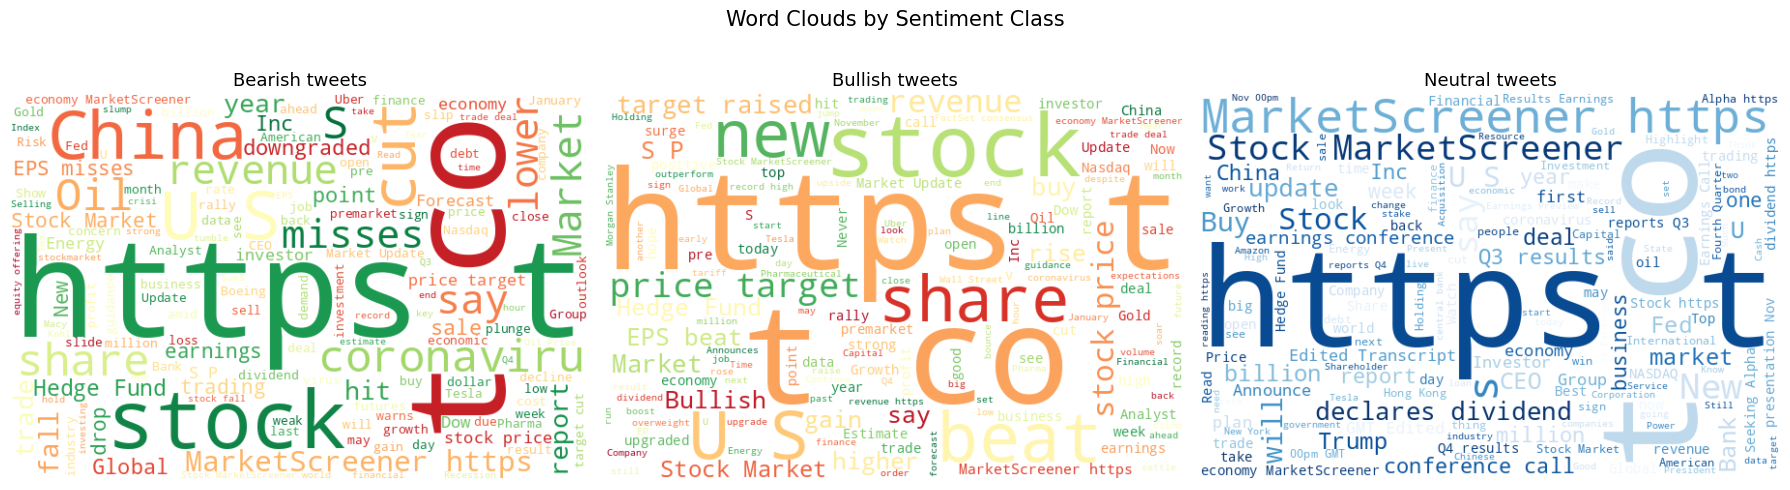

In [8]:
plot_wordclouds(train_df, text_col="text", label_col="label")

From the word clouds before preprocessing, frequent tokens are still dominated by noisy market syntax (tickers, short boilerplate fragments, and repeated symbols). This motivates the use of stronger normalization before feature extraction.

### 1.5 Top Tokens per Class (before preprocessing)

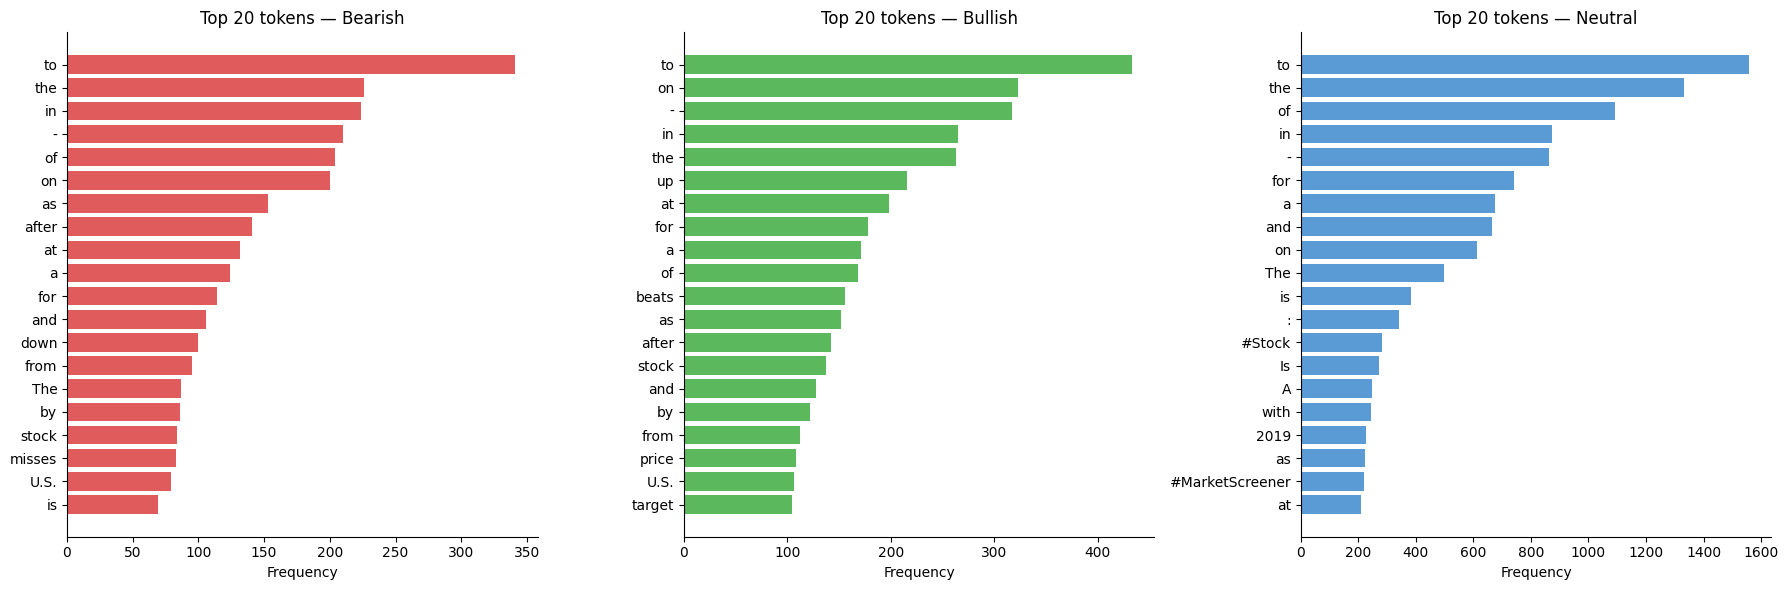

In [9]:
plot_top_tokens(train_df, text_col="text", label_col="label", n=20)

## 2. Data Preprocessing

The preprocessing logic is now mode-based in `preprocess_pipeline` (from `text_mining_utils.py`), with two clear routes depending on the modeling approach.

### Available modes
1. `mode="classical"` (for BoW / TF-IDF / Word2Vec style pipelines)
   - Regex noise removal
   - Tokenization (TweetTokenizer)
   - Stop word removal
   - POS-aware lemmatization

2. `mode="transformer"` (for Transformer Encoder models)
   - Lightweight normalization with placeholder tokens
   - Examples: `[URL]`, `[USER]`, `[CASHTAG]`, `[HASHTAG]`, `[RT]`
   - Keeps richer context for model tokenizers, instead of aggressive token filtering

This keeps one unified API while matching best practices for classical NLP vs transformer workflows.

### 2.1 Before / After Examples - Classical Mode

In [10]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,nokia stock price target raise mkm partner
1,Russia backs OPEC+ oil output cuts,russia back opec oil output cut
2,Many workers don't have access to retirement s...,many worker access retirement saving program e...
3,About 200 Google employees demonstrated outsid...,google employee demonstrate outside company sa...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,idg energy investment voluntary announcement i...
5,Vans parent VF Corp. says 60% of China stores ...,van parent vf corp say china store close coron...
6,AU Optronics reports Q4 results,au optronics report q result
7,$KZR Kezar Life Sciences Highlights Therapeuti...,kezar life science highlight therapeutic poten...
8,U.S. Oil Inventories Rise More Than Expected #...,u oil inventory rise expect wti stock marketsc...
9,A Big Step Forward For the Treatment of ALS,big step forward treatment al


### 2.2 Before / After Examples - Transformer Mode

In [13]:
examples_df = show_preprocessing_examples(
    train_df, text_col="text", n=10, pipeline_fn=preprocess_pipeline, mode = "transformer"
)
examples_df

,original,preprocessed
0,Nokia stock price target raised to $6.00 from ...,Nokia stock price target raised to $6.00 from ...
1,Russia backs OPEC+ oil output cuts,Russia backs OPEC+ oil output cuts
2,Many workers don't have access to retirement s...,Many workers don't have access to retirement s...
3,About 200 Google employees demonstrated outsid...,About 200 Google employees demonstrated outsid...
4,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...,IDG Energy Investment : VOLUNTARY ANNOUNCEMENT...
5,Vans parent VF Corp. says 60% of China stores ...,Vans parent VF Corp. says 60% of China stores ...
6,AU Optronics reports Q4 results,AU Optronics reports Q4 results
7,$KZR Kezar Life Sciences Highlights Therapeuti...,[CASHTAG] Kezar Life Sciences Highlights Thera...
8,U.S. Oil Inventories Rise More Than Expected #...,U.S. Oil Inventories Rise More Than Expected [...
9,A Big Step Forward For the Treatment of ALS,A Big Step Forward For the Treatment of ALS


### 2.3 Top Tokens After Preprocessing

Compare the top tokens before and after — confirms noise removal and stop word filtering worked.

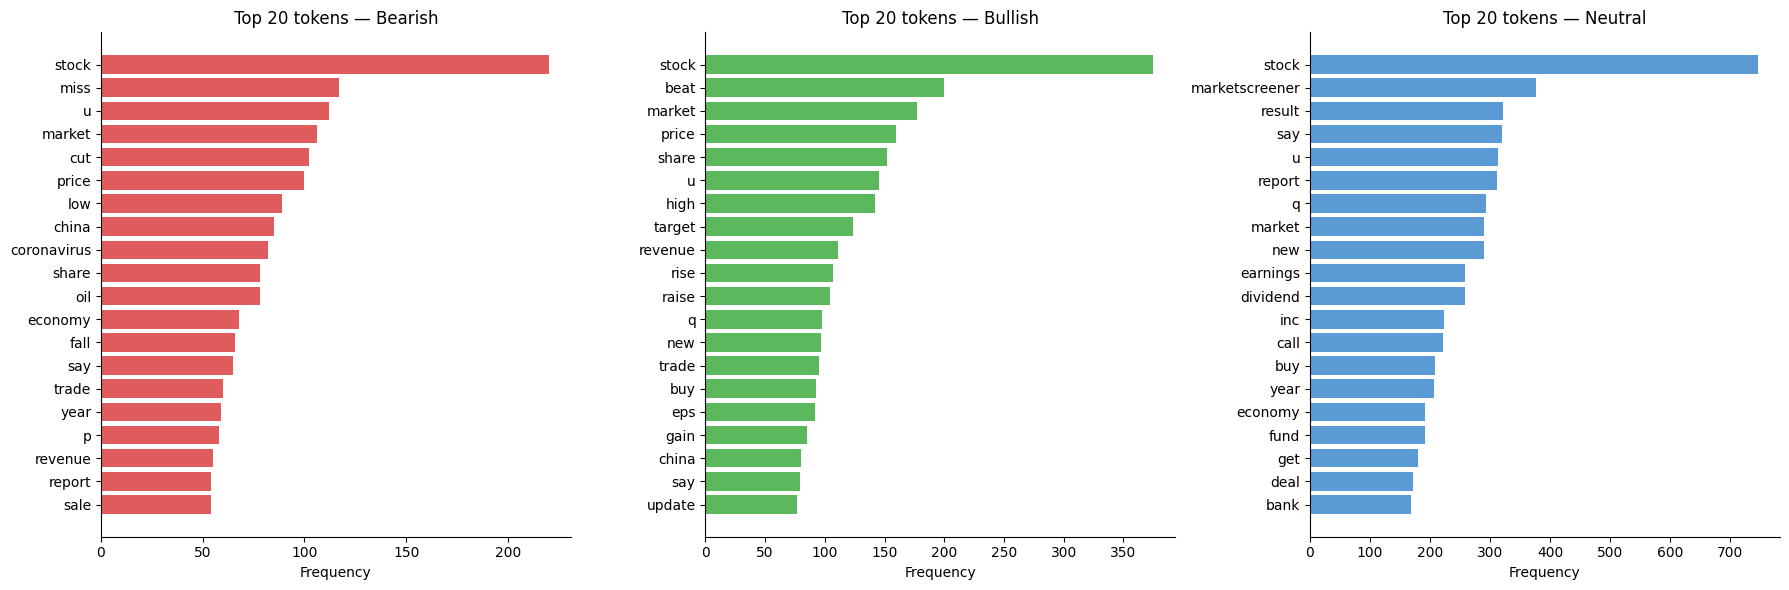

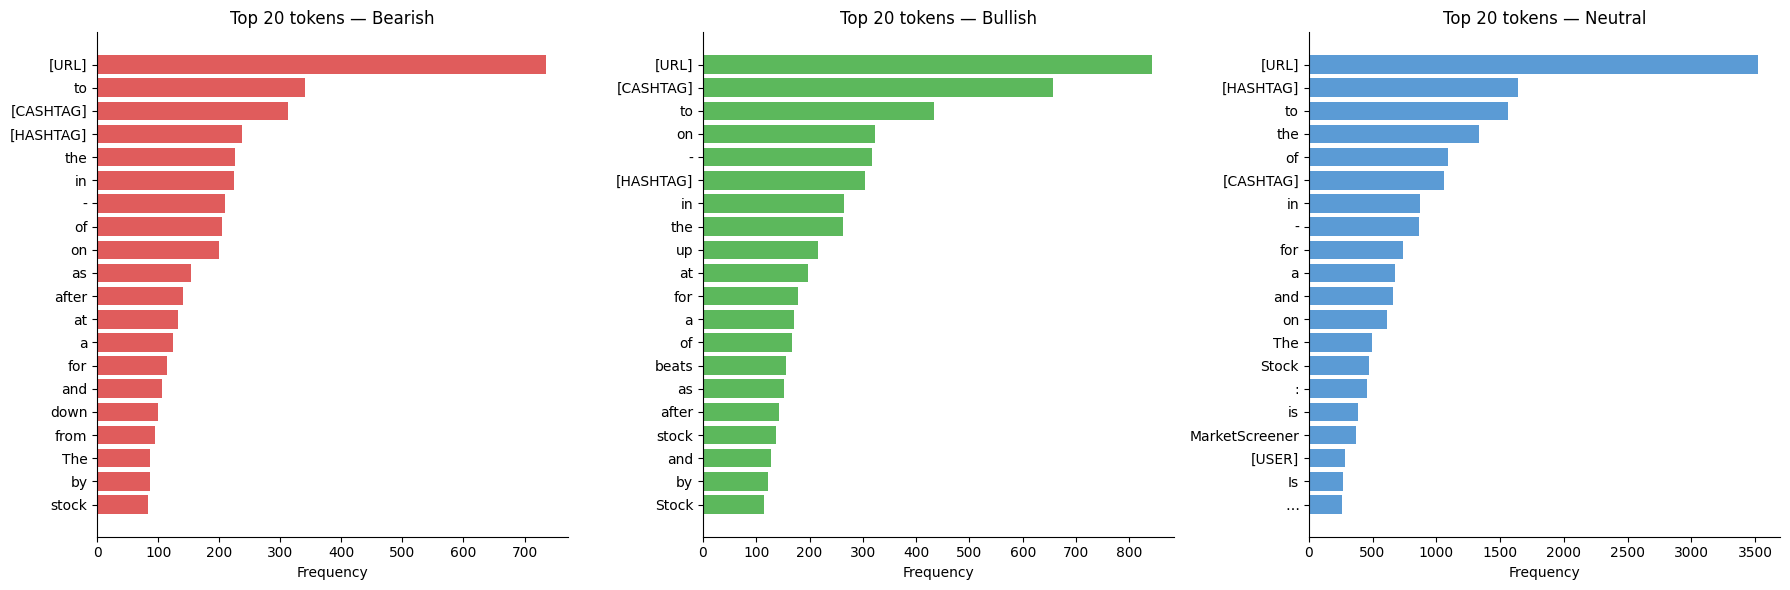

In [14]:
# Build a temporary df with preprocessed text for the full train set (for visualization only)
train_df["text_classical"] = preprocess_pipeline(train_df["text"])
train_df["text_transformer"] = preprocess_pipeline(train_df["text"], mode="transformer")

plot_top_tokens(train_df, text_col="text_classical", label_col="label", n=20)
plot_top_tokens(train_df, text_col="text_transformer", label_col="label", n=20)

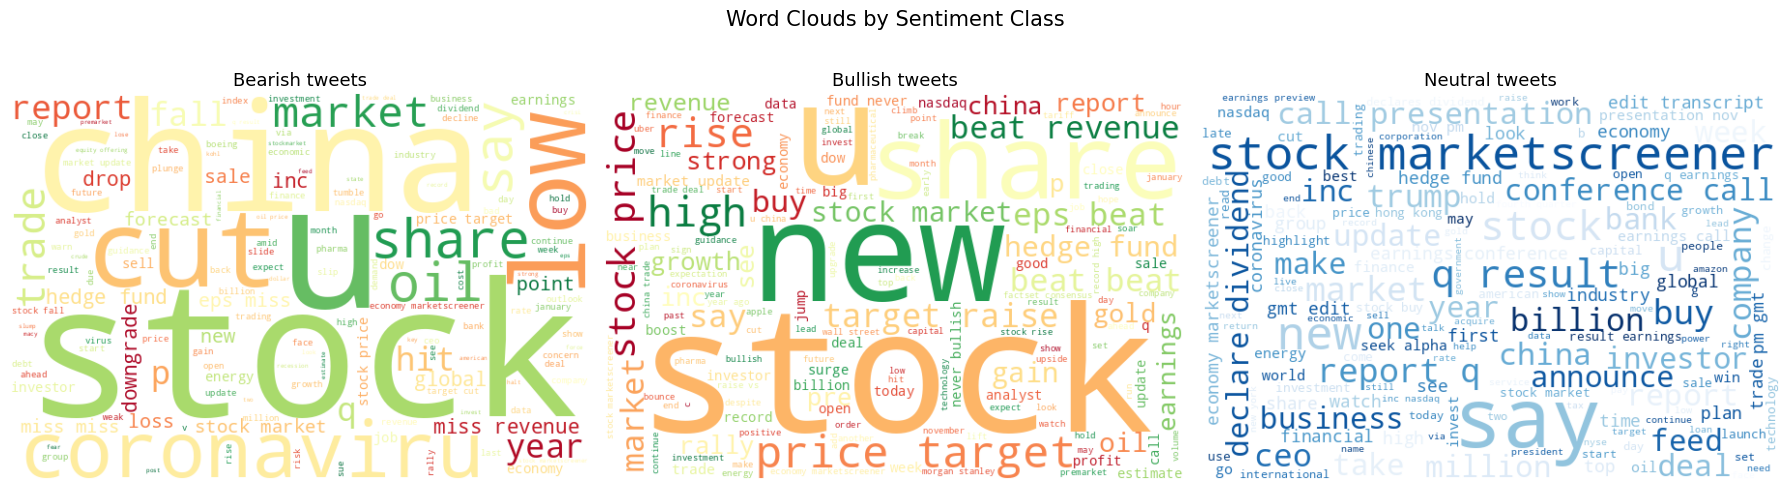

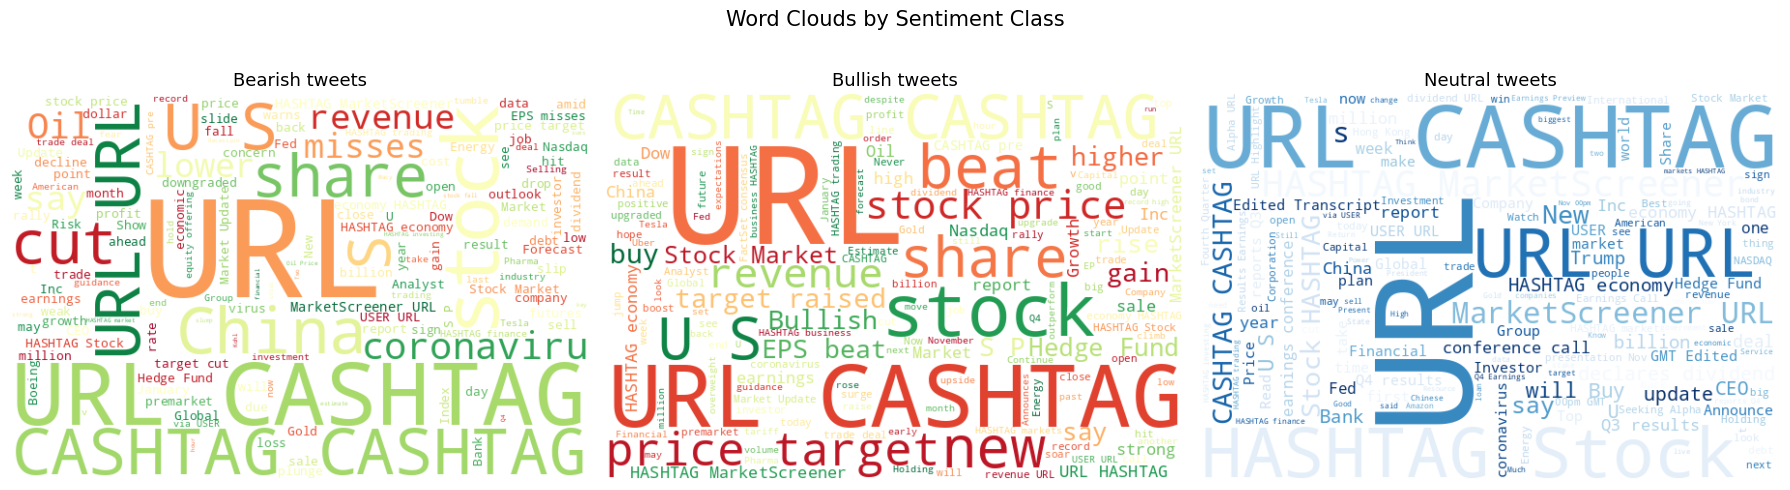

In [15]:
# Word clouds after preprocessing
plot_wordclouds(train_df, text_col="text_classical", label_col="label")
plot_wordclouds(train_df, text_col="text_transformer", label_col="label")

Preprocessing results are consistent with the intended behavior of both routes:
- Classical mode highlights cleaner semantic tokens useful for traditional vectorizers.
- Transformer mode preserves contextual cues through placeholder tokens such as `[URL]`, `[USER]`, and `[CASHTAG]`, which can help downstream transformer tokenizers retain structure.

# 3. Data Split

# 4. Feature Engineering